<div style="padding:24px;border-left:8px solid #C99700;background:#071B33;color:white;border-radius:8px">
<h1 style="margin:0">Lab 07 · SPX Surface Identification and Heston Validation</h1>
<p style="font-size:17px;margin-bottom:0">A structural model earns credibility through identification, arbitrage controls, untouched quotes, and visible failure modes.</p>
</div>

**Question.** Does one Heston parameter vector explain four SPX smiles better than a maturity-level flat-volatility null?

**Pre-declared design.** Robust European put–call parity identifies forwards and discounts. Out-of-the-money prices are inverted with Black's forward formula. Raw SVI must pass dense-grid butterfly, wing, and calendar restrictions. Every fourth selected strike is excluded before Heston calibration. The evidence is an immutable delayed-chain snapshot for 27 August 2026—not a physical-return forecast or an exchange-certified NBBO.

In [1]:
from pathlib import Path
import hashlib, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def find_root():
    here = Path.cwd().resolve()
    for candidate in (here, *here.parents):
        if (candidate/'projects'/'volatility_surface'/'run_research.py').exists(): return candidate
    raise FileNotFoundError('Repository root not found')

ROOT=find_root(); OUT=ROOT/'projects'/'volatility_surface'/'output'
plt.style.use('seaborn-v0_8-whitegrid')
NAVY,BLUE,GOLD,RED,GREEN='#071B33','#1676B8','#C99700','#C84C4C','#26866A'
pd.options.display.float_format='{:,.6f}'.format

manifest={}
for line in (OUT/'manifest.sha256').read_text().splitlines():
    digest,name=line.split(maxsplit=1); manifest[name]=digest
checks={name: hashlib.sha256((OUT/name).read_bytes()).hexdigest()==digest for name,digest in manifest.items()}
assert checks and all(checks.values()), 'Snapshot manifest verification failed'
meta=json.loads((OUT/'snapshot_metadata.json').read_text())
parity=pd.read_csv(OUT/'parity_estimates.csv')
svi=pd.read_csv(OUT/'svi_diagnostics.csv')
params=pd.read_csv(OUT/'heston_parameters.csv')
starts=pd.read_csv(OUT/'heston_multistart.csv')
validation=pd.read_csv(OUT/'heston_validation.csv')
summary=pd.read_csv(OUT/'calibration_summary.csv')
print(f"Verified {len(checks)} SHA-256 entries | {meta['ticker']} | session {meta['reference_session_date']}")
print(f"Expirations: {', '.join(meta['expirations'])} | spot: {meta['spot_reference']:,.2f}")

Verified 11 SHA-256 entries | ^SPX | session 2026-08-27
Expirations: 2026-09-18, 2026-11-20, 2027-02-19, 2027-08-20 | spot: 7,730.99


## 1. Identification before interpolation

European parity is a cross-sectional measurement equation:
$$C(K,T)-P(K,T)=D(T)[F(T)-K]=\alpha_T-\beta_TK.$$
Two distinct strikes identify $D=\beta$ and $F=\alpha/\beta$ exactly in a frictionless synchronous market. Here a soft-$L^1$ fit, liquidity weights, timestamp-gap diagnostics, and an economically declared 0–15% rate interval acknowledge stale transactions. A bound hit is retained as a warning.

The SVI total variance is
$$w(k)=a+b[\rho(k-m)+\sqrt{(k-m)^2+\sigma^2}],\qquad k=\log(K/F).$$
Beyond positive variance and Lee wing slopes, butterfly admissibility is audited through
$$g(k)=\left(1-\frac{kw'}{2w}\right)^2-\frac{(w')^2}{4}\left(\frac1w+\frac14\right)+\frac12w''\ge0.$$
Later-maturity total variance must also remain above every earlier slice on a common dense grid.

,expiration,maturity_years,forward,discount,rate_percent,parity_rmse,parity_pairs,median_call_put_time_gap_minutes,discount_at_upper_bound
0,2026-09-18,0.060233,"7,740.847105",0.997759,3.724452,4.936009,7,123.183333,False
1,2026-11-20,0.232717,"7,784.275444",1.000000,0.000000,11.107664,7,289.016667,True
2,2027-02-19,0.481862,"7,872.540686",0.966734,7.021133,1.922534,5,71.050000,False
3,2027-08-20,0.980151,"8,011.143253",0.948552,5.388832,6.043165,10,48.175000,False


,expiration,quotes,iv_rmse,inside_empirical_noise_fraction,minimum_total_variance,minimum_butterfly_g,minimum_calendar_variance_gap,left_wing_slope,right_wing_slope
0,2026-09-18,152,0.004459,0.907895,0.000625,0.000000,NaN,0.054331,0.050145
1,2026-11-20,115,0.002152,0.982609,0.003139,0.059973,0.000263,0.099276,0.057865
2,2027-02-19,64,0.001465,0.750000,0.007253,0.165688,0.000589,0.128934,0.051587
3,2027-08-20,60,0.001265,0.800000,0.017382,0.319766,0.005721,0.162995,0.051632


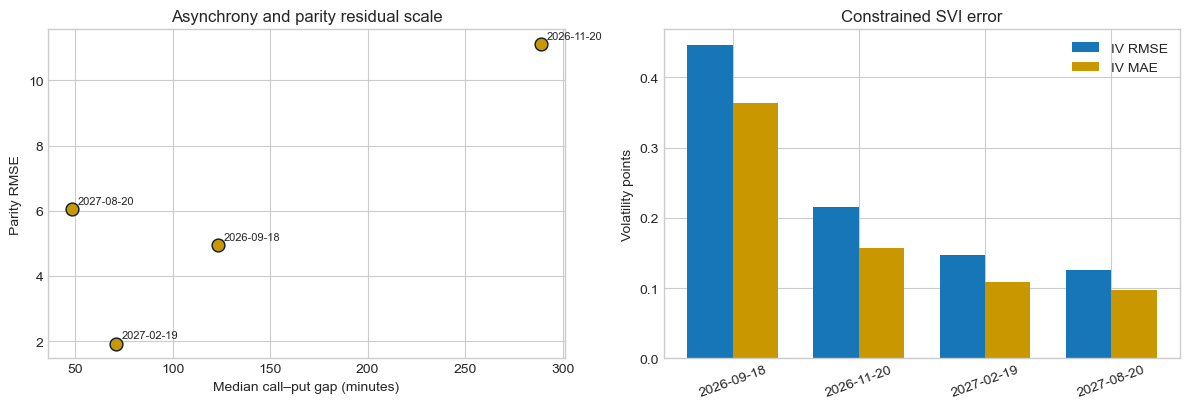

Certificate passed: positive variance, non-negative butterfly g, admissible wings, no calendar inversion.


In [2]:
parity['rate_percent']=100*parity['implied_continuous_rate']
parity['discount_at_upper_bound']=np.isclose(parity['discount'],1.0,atol=1e-7)
display(parity[['expiration','maturity_years','forward','discount','rate_percent','parity_rmse',
                'parity_pairs','median_call_put_time_gap_minutes','discount_at_upper_bound']])
display(svi[['expiration','quotes','iv_rmse','inside_empirical_noise_fraction','minimum_total_variance',
             'minimum_butterfly_g','minimum_calendar_variance_gap','left_wing_slope','right_wing_slope']])
assert parity['parity_pairs'].min()>=5 and parity['discount_at_upper_bound'].sum()==1
assert (svi['minimum_total_variance']>0).all() and (svi['minimum_butterfly_g']>=-1e-8).all()
assert (svi['minimum_calendar_variance_gap'].dropna()>=-1e-8).all()
assert (svi[['left_wing_slope','right_wing_slope']]<2).all().all()

fig,axes=plt.subplots(1,2,figsize=(12,4.2))
axes[0].scatter(parity['median_call_put_time_gap_minutes'],parity['parity_rmse'],s=85,c=GOLD,edgecolor=NAVY)
for row in parity.itertuples():
    axes[0].annotate(str(row.expiration),(row.median_call_put_time_gap_minutes,row.parity_rmse),
                     xytext=(4,4),textcoords='offset points',fontsize=8)
axes[0].set(title='Asynchrony and parity residual scale',xlabel='Median call–put gap (minutes)',ylabel='Parity RMSE')
x=np.arange(len(svi)); width=.36
axes[1].bar(x-width/2,100*svi['iv_rmse'],width,label='IV RMSE',color=BLUE)
axes[1].bar(x+width/2,100*svi['iv_mae'],width,label='IV MAE',color=GOLD)
axes[1].set_xticks(x,svi['expiration'].astype(str),rotation=20)
axes[1].set(title='Constrained SVI error',ylabel='Volatility points'); axes[1].legend()
fig.tight_layout(); plt.show()
print('Certificate passed: positive variance, non-negative butterfly g, admissible wings, no calendar inversion.')

## 2. Structural compression and an untouched test

Under the pricing measure,
$$dS_t=(r-q)S_tdt+\sqrt{v_t}S_tdW_t^S,$$
$$dv_t=\kappa(\theta-v_t)dt+\xi\sqrt{v_t}dW_t^v,\qquad d\langle W^S,W^v\rangle_t=\rho\,dt.$$
Fourier inversion supplies prices. Calibration divides price errors by Black vega, so the least-squares objective approximates implied-volatility error. Five dispersed starts probe local minima. Local Jacobian errors describe curvature, not sampling uncertainty for dependent noisy quotes.

The null uses each maturity's liquidity-weighted mean training volatility. The decisive comparison uses 24 strikes excluded before either Heston assessment or benchmark evaluation.

,parameter,estimate,local_standard_error,lower_bound,upper_bound,near_boundary
0,kappa,2.845909,0.990346,0.050000,12.000000,False
1,theta,0.055874,0.008664,0.005000,0.600000,False
2,vol_of_vol,1.109120,0.106951,0.050000,3.000000,False
3,rho,-0.679852,0.029606,-0.990000,0.990000,False
4,initial_variance,0.016819,0.001532,0.005000,0.600000,False


,mean,standard_deviation,coefficient_of_variation_abs
kappa,2.845914,0.000184,0.000065
theta,0.055874,0.000001,0.000026
vol_of_vol,1.109107,0.000024,0.000021
rho,-0.679856,0.000003,0.000004
initial_variance,0.016819,0.000000,0.000008


Multi-start objective spread: 0.00154889 | Feller slack: -0.912123


quotes           price_rmse          iv_equivalent_rmse           \
model        flat    heston       flat   heston               flat   heston   
sample                                                                        
holdout 24.000000 24.000000  50.282911 5.446775           0.044594 0.014642   
train   76.000000 76.000000  49.918760 4.326884           0.041158 0.014214   

        iv_equivalent_mae          inside_empirical_noise_fraction           
model                flat   heston                            flat   heston  
sample                                                                       
holdout          0.038268 0.009034                        0.083333 0.583333  
train            0.036063 0.008124                        0.184211 0.592105

Held-out IV-equivalent RMSE reduction versus null: 67.2%


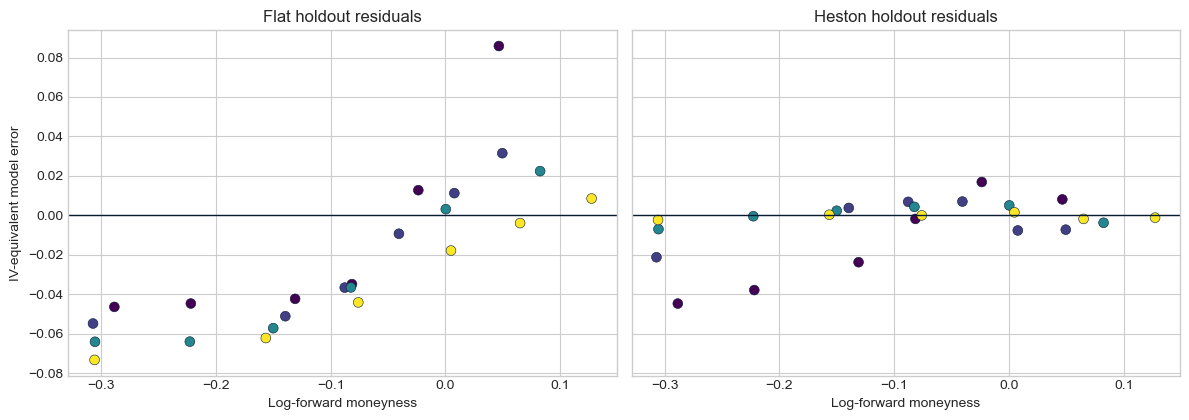

In [3]:
display(params[['parameter','estimate','local_standard_error','lower_bound','upper_bound','near_boundary']])
cols=['kappa','theta','vol_of_vol','rho','initial_variance']
stability=pd.DataFrame({'mean':starts[cols].mean(),'standard_deviation':starts[cols].std(ddof=1),
                        'coefficient_of_variation_abs':starts[cols].std(ddof=1)/starts[cols].mean().abs()})
display(stability)
spread=starts['scaled_residual_sse'].max()-starts['scaled_residual_sse'].min()
best=starts.loc[starts['scaled_residual_sse'].idxmin()]
print(f"Multi-start objective spread: {spread:.6g} | Feller slack: {best['feller_slack']:.6f}")
assert starts['success'].astype(bool).all() and spread<.01 and best['feller_slack']<0

comparison=summary.pivot(index='sample',columns='model',values=['quotes','price_rmse','iv_equivalent_rmse',
                                                                 'iv_equivalent_mae','inside_empirical_noise_fraction'])
display(comparison)
flat=summary.query("model=='flat' and sample=='holdout'")['iv_equivalent_rmse'].iloc[0]
heston=summary.query("model=='heston' and sample=='holdout'")['iv_equivalent_rmse'].iloc[0]
print(f'Held-out IV-equivalent RMSE reduction versus null: {100*(1-heston/flat):.1f}%')
assert heston<flat

hold=validation.query("split=='holdout'")
fig,axes=plt.subplots(1,2,figsize=(12,4.3),sharey=True)
for ax,model,color in zip(axes,['flat','heston'],[RED,GREEN]):
    ax.scatter(hold['log_moneyness'],hold[f'{model}_iv_equivalent_error'],c=hold['maturity_years'],
               cmap='viridis',s=50,edgecolor=NAVY,linewidth=.4)
    ax.axhline(0,color=NAVY,lw=1); ax.set(title=f'{model.title()} holdout residuals',xlabel='Log-forward moneyness')
axes[0].set_ylabel('IV-equivalent model error'); fig.tight_layout(); plt.show()

## 3. Model-risk verdict

**Supported.** Heston materially outperforms the declared flat-volatility null on untouched strikes; constrained SVI passes the declared dense-grid static-arbitrage tests; dispersed Heston starts reach effectively the same optimum.

**Not supported.** One date cannot establish forecast ability, physical probabilities, hedge performance, or Heston as the true law of the surface.

**Red flags retained.** One parity discount touches its upper bound; public last transactions are asynchronous; the best unrestricted Heston fit violates the Feller sufficient condition; and local standard errors omit feed noise and cross-contract dependence.

**Defensible extensions.** Freeze this protocol across many dates; compare restricted-Feller and unrestricted fits; use licensed bid/ask histories; evaluate delta–vega hedges after costs; and benchmark local volatility, SSVI, and rough volatility.